# HB States Metrology Optimization & Comparison
This notebook initializes Holland-Burnett (HB) states for N photons and d phases, computes their QFI and CRB, and natively compares them against previously obtained **Optimized States** under identical parameters (saved in `Project_A_files/optimized_states_common_eta.csv`).

In [1]:
import numpy as np
from itertools import product
from qutip import *
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.gridspec import GridSpec
import pandas as pd
import os
import ast


In [2]:
def generate_combinations(K, N):
    all_combinations = product(range(N + 1), repeat=K)
    return [comb for comb in all_combinations if sum(comb) <= N]

def diagonalize(rho):
    return rho.eigenstates()

def compute_rho_derivative(rho, vals, vecs, generators, a):
    n_a = generators[a]
    U = Qobj(np.hstack([v.full() for v in vecs]), dims=[rho.dims[0], rho.dims[0]])
    n_a_eigen = (U.dag() * n_a * U).full()
    diffs = vals[np.newaxis, :] - vals[:, np.newaxis]
    return -1j * diffs * n_a_eigen

def calculate_QFIM(rho, vals, vecs, generators):
    dim = len(vals)
    K = len(generators)
    qfim = np.zeros((K, K))
    derivatives_eigen = [compute_rho_derivative(rho, vals, vecs, generators, a) for a in range(K)]

    for a in range(K):
        for b in range(a, K):
            term_sum = 0
            for n in range(dim):
                for m in range(dim):
                    v_sum = vals[n] + vals[m]
                    if v_sum > 1e-14:
                        elem_a = derivatives_eigen[a][n, m]
                        elem_b = derivatives_eigen[b][m, n]
                        term_sum += (2.0 / v_sum) * np.real(elem_a * elem_b)
            qfim[a, b] = term_sum
            qfim[b, a] = term_sum
    return qfim

import math
def N_free(initial_signal_state, eta_vec, N, K):
    D = N + 1
    rho = ket2dm(initial_signal_state) if initial_signal_state.isket else initial_signal_state
    for i in range(K):
        eta = eta_vec[i]
        kraus_ops = []
        for k_loss in range(D):
            E_k = np.zeros((D, D))
            for n in range(k_loss, D):
                E_k[n-k_loss, n] = np.sqrt(math.comb(n, k_loss) * (eta**(n-k_loss)) * ((1-eta)**k_loss))
            ops = [qeye(D)] * K
            ops[i] = Qobj(E_k)
            kraus_ops.append(tensor(ops))
            
        rho_new = 0 * rho
        for E in kraus_ops:
            rho_new += E * rho * E.dag()
        rho = rho_new
    return rho

def N_int(initial_signal_state, eta_vec, N, K):
    D = N + 1
    a_e = tensor([qeye(D)] * K + [destroy(D)])
    h_tot = tensor([qeye(D)] * (K + 1)) * 0.0
    for i in range(K):
        theta_i = np.arccos(np.sqrt(eta_vec[i]))
        ops_s = [qeye(D)] * (K + 1); ops_s[i] = destroy(D)
        h_tot += theta_i * (tensor(ops_s).dag() * a_e - tensor(ops_s) * a_e.dag())
    V_total = h_tot.expm()
    rho_joint = ket2dm(tensor(initial_signal_state, basis(D, 0)))
    return (V_total * rho_joint * V_total.dag()).ptrace(list(range(K)))

def N_tot(initial_ket, eta_vec, p, N, K):
    if p == 1.0:
        return N_free(initial_ket, eta_vec, N, K)
    elif p == 0.0:
        return N_int(initial_ket, eta_vec, N, K)
    return p * N_free(initial_ket, eta_vec, N, K) + (1.0 - p) * N_int(initial_ket, eta_vec, N, K)


In [3]:
def initialize_HB_state(N, d, D=None):
    D = N + 1 if D is None else D
    modes = d + 1
    n_list = [N // modes] * modes
    for i in range(N % modes):
        n_list[i] += 1
        
    omega = np.exp(2j * np.pi / modes)
    
    a_ops = []
    for i in range(modes):
        ops = [qeye(D)] * modes
        ops[i] = create(D)
        a_ops.append(tensor(ops))
        
    b_ops = []
    for k in range(modes):
        b_k = 0
        for j in range(modes):
            b_k += (1.0 / np.sqrt(modes)) * (omega ** (j * k)) * a_ops[j]
        b_ops.append(b_k)
        
    state = tensor([basis(D, 0)] * modes)
    for k in range(modes):
        for _ in range(n_list[k]): state = b_ops[k] * state

    state = state.unit() 
    combinations = generate_combinations(d, N)
    basis_kets_K = [tensor([basis(D, n_signal) for n_signal in comb]) for comb in combinations]

    coeffs = []
    for comb in combinations:
        n_0 = N - sum(comb)
        target_ket = tensor([basis(D, n_0)] + [basis(D, n_i) for n_i in comb])
        coeffs.append(target_ket.overlap(state))
        
    return np.array(coeffs), basis_kets_K, combinations

def construct_ket(coeffs, basis_kets):
    return sum(coeffs[i] * basis_kets[i] for i in range(len(coeffs))).unit()


In [4]:


def evaluate_state_metrics(initial_ket, N, K, eta_vec, p):
    rho_out = N_tot(initial_ket, eta_vec, p, N, K)
    vals, vecs = diagonalize(rho_out)
    
    D = N + 1
    generators = []
    for i in range(K):
        ops = [qeye(D)] * K
        ops[i] = num(D)
        generators.append(tensor(ops))
        
    qfim = calculate_QFIM(rho_out, vals, vecs, generators)
    max_qfi = np.trace(qfim)
    total_var = np.trace(np.linalg.pinv(qfim)) if np.linalg.det(qfim) != 0 else np.inf
    return max_qfi, total_var

def evaluate_grid(N, d, state_coeffs, basis_kets, eta_values, p_values):
    results = []
    initial_ket = construct_ket(state_coeffs, basis_kets)
    for eta in eta_values:
        for p in p_values:
            qfi, crb = evaluate_state_metrics(initial_ket, N, d, [eta]*d, p)
            results.append({"eta": eta, "p": p, "max_qfi": qfi, "total_var": crb})
            print(f"HB Computed eta={eta}, p={p:.1f} | QFI={qfi:.3f}, CRB={crb:.3f}")
    return pd.DataFrame(results)

def format_optimized_database(filepath):
    if not os.path.exists(filepath):
        print(f"File {filepath} not found.")
        return None
    df = pd.read_csv(filepath)
    def extract_eta(eta_str):
        clean = str(eta_str).replace('np.float64(', '').replace(')', '').replace('[', '').replace(']', '').split(',')
        return float(clean[0])
    df['eta'] = df['eta_vec'].apply(extract_eta)
    if 'total_variance' in df.columns:
        df.rename(columns={'total_variance': 'total_var'}, inplace=True)
    return df

def format_ket_latex(coeffs, combs):
    terms = []
    for c, comb in zip(coeffs, combs):
        if abs(c) > 0.01:
            c_cpx = complex(c)
            if abs(c_cpx.imag) < 1e-4:
                c_str = f"{c_cpx.real:.2f}"
            else:
                c_str = f"{c_cpx:.2f}"
            
            terms.append(f"{c_str}|{','.join(map(str, comb))}\\rangle")
    return " + ".join(terms).replace("+ -", "- ")

def plot_hb_vs_optimized(df_hb, df_opt, hb_coeffs, combs, N_target, K_target, eta_target, output_dir, file_prefix="HB_vs_Optimized"):
    plt.rcParams.update({'figure.facecolor': 'white', 'axes.facecolor': 'white', 'savefig.facecolor': 'white'})
    
    subset_hb = df_hb[np.isclose(df_hb['eta'], eta_target, atol=1e-3)].sort_values(by='p')
    if df_opt is not None:
        subset_opt = df_opt[np.isclose(df_opt['eta'], eta_target, atol=1e-3)].sort_values(by='p')
        valid_ps = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
        subset_opt = subset_opt[pd.to_numeric(subset_opt['p']).apply(lambda x: any(np.isclose(x, v, atol=1e-3) for v in valid_ps))]
    else:
        subset_opt = pd.DataFrame()
        
    if subset_hb.empty and subset_opt.empty: return
        
    d, N = K_target, N_target
    noon_val = (d**3) / (N**2)
    computed_multipixel_crb = (d * (1 + np.sqrt(d))**2) / (4 * (N**2))
    
    fig, ax_qfi = plt.subplots(figsize=(10.5, 6.5))
    
    ket_labels_handles = []

    if not subset_opt.empty:
        colors_opt = plt.cm.viridis(np.linspace(0, 1, len(subset_opt)))
        for i, (_, row) in enumerate(subset_opt.iterrows()):
            lbl = r"CRB of $|\psi_{opt}(p)\rangle$" if i == 0 else ""
            scatter_h = ax_qfi.scatter(row['p'], row['total_var'], color=colors_opt[i], marker='*', s=300, edgecolors='black', zorder=4, alpha=0.9, label=lbl)
            
            c_str = str(row['coeffs']).split(',')
            cb_str = str(row['combinations']).split(';')
            try:
                c_arr = [float(x) for x in c_str if x.strip()]
                cb_arr = [tuple(map(int, x.split(','))) for x in cb_str if x.strip()]
                latex_ket = f"$p={row['p']:.1f}: {format_ket_latex(c_arr, cb_arr)}$"
                ket_labels_handles.append((scatter_h, latex_ket))
            except:
                pass


    if not subset_hb.empty:
        for i, (_, row) in enumerate(subset_hb.iterrows()):
            lbl = r"CRB of $|\psi_{HB}(p)\rangle$" if i == 0 else ""
            hb_h = ax_qfi.scatter(row['p'], row['total_var'], s=120, color='dodgerblue', edgecolors='black', zorder=5, label=lbl)

    ax_qfi.axhline(y=noon_val, color='red', linestyle='--', linewidth=2, zorder=2, label=f"Heisenberg Limit ($\\approx {noon_val:.2f}$)")
    ax_qfi.axhline(y=computed_multipixel_crb, color='dodgerblue', linestyle='-.', linewidth=2, zorder=2, label=f"Multipixel CRB ($\\approx {computed_multipixel_crb:.2f}$)")

    all_vars = list(subset_hb['total_var'].values) + ([noon_val, computed_multipixel_crb])
    if not subset_opt.empty: all_vars.extend(subset_opt['total_var'].values)
    v_min, v_max = min(all_vars), max(all_vars)
    padding = (v_max - v_min) * 0.15 if v_max > v_min else 0.2
    
    ax_qfi.set_ylim(v_min - padding * 0.5, v_max + padding * 3)

    ax_qfi.set_xlabel("Mixture Parameter $p$ (0 = Full Interaction, 1 = No Interaction)", fontsize=11)
    ax_qfi.set_ylabel(r"Minimized $\mathrm{Tr}(\mathcal{I}_{\boldsymbol{\theta}}^{-1})$", fontsize=11)
    ax_qfi.grid(True, linestyle=':', alpha=0.4)
    ax_qfi.set_title(f"State Comparison (HB vs Optimized CRB) for $\eta={eta_target}$", fontsize=13, pad=10)

    handles, labels = ax_qfi.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    leg1 = ax_qfi.legend(by_label.values(), by_label.keys(), loc='upper left', fontsize=10, frameon=True, facecolor='white')
    ax_qfi.add_artist(leg1)
    
    l_hand = [h[0] for h in ket_labels_handles] if ket_labels_handles else []
    l_lab = [h[1] for h in ket_labels_handles] if ket_labels_handles else []
    
    if not subset_hb.empty:
        hb_ket_str = f"$|HB\\rangle: {format_ket_latex(hb_coeffs, combs)}$" 
        l_hand.append(hb_h)
        l_lab.append(hb_ket_str)
        
    if l_hand:
        title_str = r"$\mathbf{Optimized\ States\ (\eta=" + str(eta_target) + ")}$" if ket_labels_handles else r"$\mathbf{HB\ State\ (\eta=" + str(eta_target) + ")}$"
        leg2 = plt.legend(l_hand, l_lab, loc='center left', bbox_to_anchor=(1.02, 0.5), title=title_str, fontsize=9, frameon=True)
    
    plt.subplots_adjust(left=0.08, bottom=0.12, right=0.6, top=0.92)
    
    import os
    os.makedirs(output_dir, exist_ok=True)
    filename = f"{output_dir}/{file_prefix}_eta_{eta_target}.png"
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    print(f"Saved aesthetically matched scatter plot to {filename}")
    plt.close()



<>:109: SyntaxWarning: invalid escape sequence '\e'
<>:109: SyntaxWarning: invalid escape sequence '\e'
C:\Users\omrym\AppData\Local\Temp\ipykernel_33492\151974378.py:109: SyntaxWarning: invalid escape sequence '\e'
  ax_qfi.set_title(f"State Comparison (HB vs Optimized CRB) for $\eta={eta_target}$", fontsize=13, pad=10)


In [5]:
# == 1. Variables Definition ==
N_photons = 3
d_phases = 2
out_folder = "plots_output/HB_vs_Optimized"

hb_coeffs, basis_kets, combs = initialize_HB_state(N_photons, d_phases)

# == 2. Evaluation on Augmented Grid ==
p_grid = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
# Requested explicit extended eta range constraints
eta_grid = [0.8, 0.9, 0.95, 1.0]

print("Evaluating HB State Matrix Profile...")
df_hb = evaluate_grid(N_photons, d_phases, hb_coeffs, basis_kets, eta_grid, p_grid)

# == 3. Load Project A Database ==
db_path = "Project_A_files/database_projectA_CRB.csv"
df_opt = format_optimized_database(db_path)

if df_opt is None:
    print("Warning: Project A database could not be loaded safely.")

# == 4. Generate Reproductions ==
for eta in eta_grid:
    plot_hb_vs_optimized(df_hb, df_opt, hb_coeffs, combs, N_photons, d_phases, eta, out_folder)


Evaluating HB State Matrix Profile...
HB Computed eta=0.8, p=0.0 | QFI=7.922, CRB=0.638
HB Computed eta=0.8, p=0.2 | QFI=7.598, CRB=0.649
HB Computed eta=0.8, p=0.4 | QFI=7.418, CRB=0.656
HB Computed eta=0.8, p=0.6 | QFI=7.312, CRB=0.660
HB Computed eta=0.8, p=0.8 | QFI=7.266, CRB=0.661
HB Computed eta=0.8, p=1.0 | QFI=7.278, CRB=0.659
HB Computed eta=0.9, p=0.0 | QFI=9.291, CRB=0.554
HB Computed eta=0.9, p=0.2 | QFI=9.116, CRB=0.558
HB Computed eta=0.9, p=0.4 | QFI=9.021, CRB=0.561
HB Computed eta=0.9, p=0.6 | QFI=8.963, CRB=0.562
HB Computed eta=0.9, p=0.8 | QFI=8.933, CRB=0.562
HB Computed eta=0.9, p=1.0 | QFI=8.933, CRB=0.562
HB Computed eta=0.95, p=0.0 | QFI=9.978, CRB=0.524
HB Computed eta=0.95, p=0.2 | QFI=9.893, CRB=0.526
HB Computed eta=0.95, p=0.4 | QFI=9.844, CRB=0.527
HB Computed eta=0.95, p=0.6 | QFI=9.811, CRB=0.527
HB Computed eta=0.95, p=0.8 | QFI=9.793, CRB=0.528
HB Computed eta=0.95, p=1.0 | QFI=9.789, CRB=0.528
HB Computed eta=1.0, p=0.0 | QFI=10.667, CRB=0.500
HB Co

Saved aesthetically matched scatter plot to plots_output/HB_vs_Optimized/HB_vs_Optimized_eta_0.8.png


Saved aesthetically matched scatter plot to plots_output/HB_vs_Optimized/HB_vs_Optimized_eta_0.9.png


Saved aesthetically matched scatter plot to plots_output/HB_vs_Optimized/HB_vs_Optimized_eta_0.95.png


Saved aesthetically matched scatter plot to plots_output/HB_vs_Optimized/HB_vs_Optimized_eta_1.0.png


In [6]:
# == 5. Higher Dimension Sweeps ==
configs = [(4, 3), (5, 3), (6, 3)]
out_folder_high = "plots_output/HB_higher_dims"

import pandas as pd
import numpy as np

for (N_target, d_target) in configs:
    print(f"\n--- Evaluating HB State for N={N_target}, d={d_target} ---")
    hb_c, b_kets, cmbs = initialize_HB_state(N_target, d_target)
    
    # We dynamically re-evaluate for the grid
    df_hb_h = evaluate_grid(N_target, d_target, hb_c, b_kets, eta_grid, p_grid)
    for eta in eta_grid:
        plot_hb_vs_optimized(df_hb_h, None, hb_c, cmbs, N_target, d_target, eta, out_folder_high, file_prefix=f"HB_alone_N{N_target}_d{d_target}")



--- Evaluating HB State for N=4, d=3 ---


HB Computed eta=0.8, p=0.0 | QFI=13.395, CRB=0.957


HB Computed eta=0.8, p=0.2 | QFI=12.847, CRB=0.973


HB Computed eta=0.8, p=0.4 | QFI=12.426, CRB=0.984


HB Computed eta=0.8, p=0.6 | QFI=12.107, CRB=0.993


...

HB Computed eta=1.0, p=1.0 | QFI=33.000, CRB=0.410


Saved aesthetically matched scatter plot to plots_output/HB_higher_dims/HB_alone_N6_d3_eta_0.8.png


Saved aesthetically matched scatter plot to plots_output/HB_higher_dims/HB_alone_N6_d3_eta_0.9.png


Saved aesthetically matched scatter plot to plots_output/HB_higher_dims/HB_alone_N6_d3_eta_0.95.png


Saved aesthetically matched scatter plot to plots_output/HB_higher_dims/HB_alone_N6_d3_eta_1.0.png


<>:34: SyntaxWarning: invalid escape sequence '\e'
<>:34: SyntaxWarning: invalid escape sequence '\e'
C:\Users\omrym\AppData\Local\Temp\ipykernel_33492\748976500.py:34: SyntaxWarning: invalid escape sequence '\e'
  ax_qfi.set_title(f"State Comparison for N={N}, d={d} (All $\eta$)", fontsize=13, pad=10)


Saved all-etas plot to plots_output/HB_vs_Optimized/HB_vs_Optimized_All_Etas_N3_d2.png


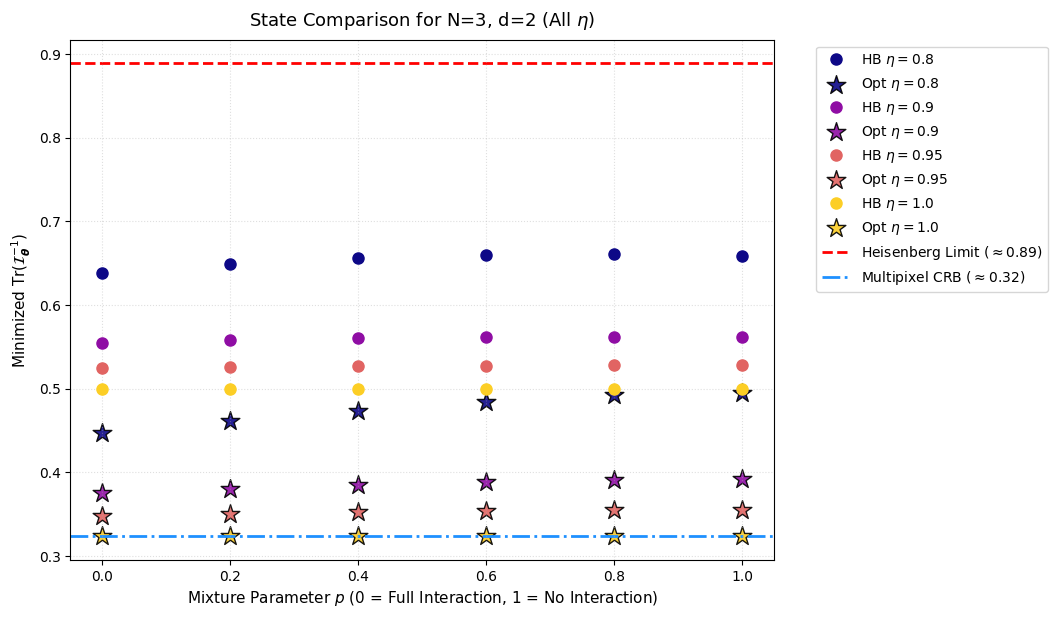

Recalculating grid for N=4, d=3 to plot all etas...


HB Computed eta=0.8, p=0.0 | QFI=13.395, CRB=0.957


HB Computed eta=0.8, p=0.2 | QFI=12.847, CRB=0.973


HB Computed eta=0.8, p=0.4 | QFI=12.426, CRB=0.984


HB Computed eta=0.8, p=0.6 | QFI=12.107, CRB=0.993


...

HB Computed eta=0.95, p=0.8 | QFI=16.395, CRB=0.792
HB Computed eta=0.95, p=1.0 | QFI=16.377, CRB=0.792


HB Computed eta=1.0, p=0.0 | QFI=18.000, CRB=0.750
HB Computed eta=1.0, p=0.2 | QFI=18.000, CRB=0.750


HB Computed eta=1.0, p=0.4 | QFI=18.000, CRB=0.750
HB Computed eta=1.0, p=0.6 | QFI=18.000, CRB=0.750


HB Computed eta=1.0, p=0.8 | QFI=18.000, CRB=0.750
HB Computed eta=1.0, p=1.0 | QFI=18.000, CRB=0.750


Saved all-etas plot to plots_output/HB_higher_dims/HB_alone_All_Etas_N4_d3.png


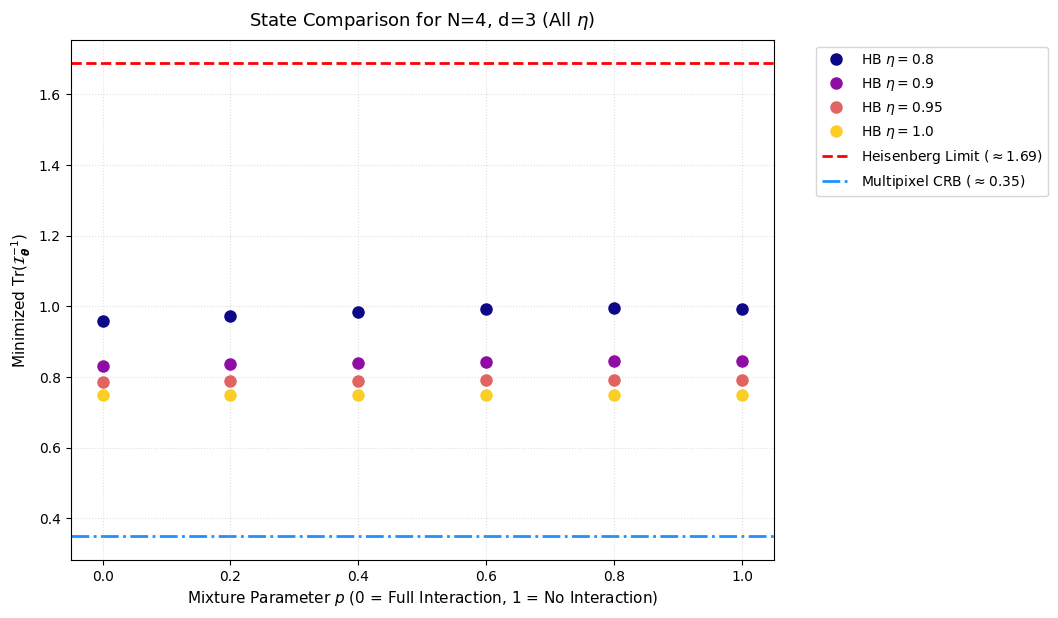

Recalculating grid for N=5, d=3 to plot all etas...


HB Computed eta=0.8, p=0.0 | QFI=16.679, CRB=0.770


HB Computed eta=0.8, p=0.2 | QFI=16.121, CRB=0.776


HB Computed eta=0.8, p=0.4 | QFI=15.726, CRB=0.777


HB Computed eta=0.8, p=0.6 | QFI=15.475, CRB=0.773


...

HB Computed eta=1.0, p=0.2 | QFI=24.750, CRB=0.545


HB Computed eta=1.0, p=0.4 | QFI=24.750, CRB=0.545


HB Computed eta=1.0, p=0.6 | QFI=24.750, CRB=0.545


HB Computed eta=1.0, p=0.8 | QFI=24.750, CRB=0.545
HB Computed eta=1.0, p=1.0 | QFI=24.750, CRB=0.545


Saved all-etas plot to plots_output/HB_higher_dims/HB_alone_All_Etas_N5_d3.png


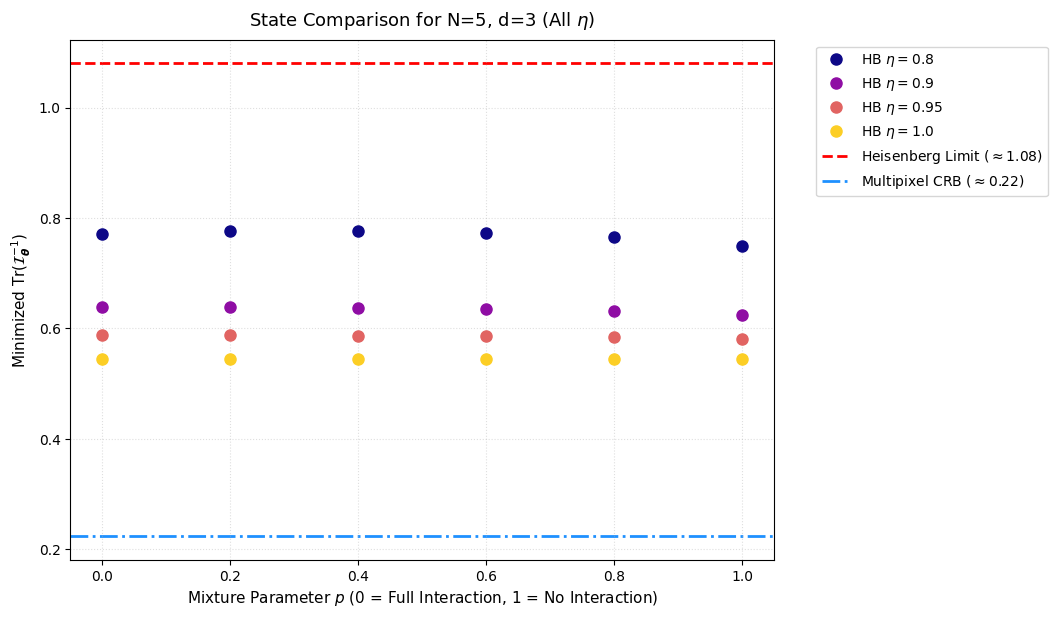

Recalculating grid for N=6, d=3 to plot all etas...


HB Computed eta=0.8, p=0.0 | QFI=22.444, CRB=0.575


HB Computed eta=0.8, p=0.2 | QFI=21.349, CRB=0.585


HB Computed eta=0.8, p=0.4 | QFI=20.510, CRB=0.592


HB Computed eta=0.8, p=0.6 | QFI=19.911, CRB=0.596


...

HB Computed eta=1.0, p=0.4 | QFI=33.000, CRB=0.410


HB Computed eta=1.0, p=0.6 | QFI=33.000, CRB=0.410


HB Computed eta=1.0, p=0.8 | QFI=33.000, CRB=0.410


HB Computed eta=1.0, p=1.0 | QFI=33.000, CRB=0.410


Saved all-etas plot to plots_output/HB_higher_dims/HB_alone_All_Etas_N6_d3.png


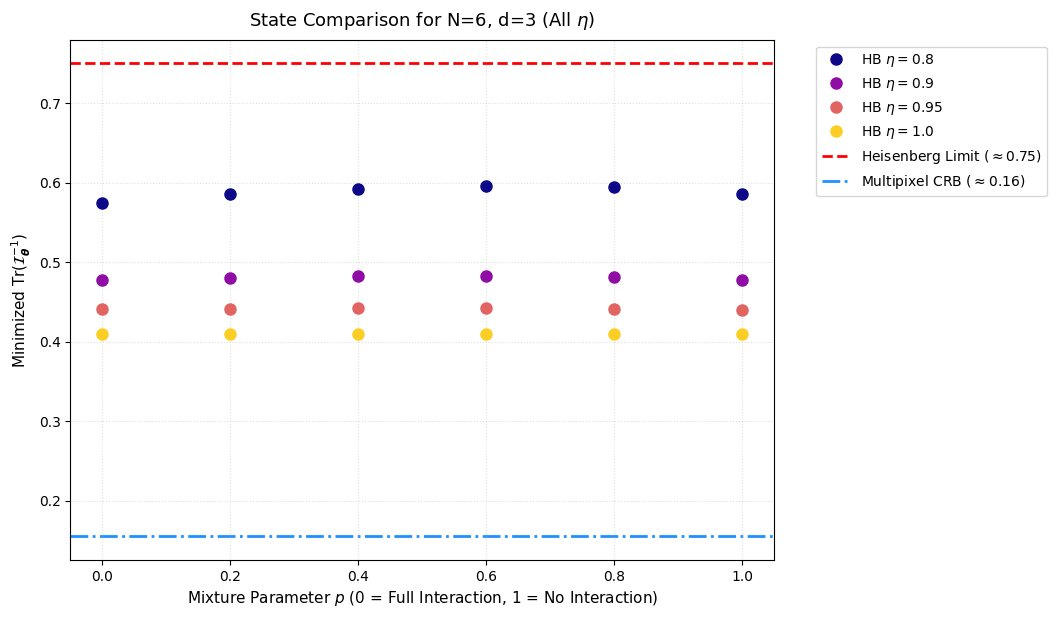

In [7]:

# == NEW PLOT: All etas in one plot ==

def plot_hb_all_etas(df_hb, df_opt, hb_coeffs, combs, N_target, K_target, eta_values, output_dir, file_prefix="HB_vs_Optimized_All_Etas"):
    plt.rcParams.update({'figure.facecolor': 'white', 'axes.facecolor': 'white', 'savefig.facecolor': 'white'})
    
    fig, ax_qfi = plt.subplots(figsize=(10.5, 6.5))
    
    colors = plt.cm.plasma(np.linspace(0, 0.9, len(eta_values)))
    
    for idx, eta in enumerate(eta_values):
        subset_hb = df_hb[np.isclose(df_hb['eta'], eta, atol=1e-3)].sort_values(by='p')
        if not subset_hb.empty:
            ax_qfi.plot(subset_hb['p'], subset_hb['total_var'], marker='o', markersize=8, 
                        linestyle='None', color=colors[idx], label=f"HB $\\eta={eta}$")
            
        if df_opt is not None:
            subset_opt = df_opt[np.isclose(df_opt['eta'], eta, atol=1e-3)].sort_values(by='p')
            valid_ps = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
            subset_opt = subset_opt[pd.to_numeric(subset_opt['p']).apply(lambda x: any(np.isclose(x, v, atol=1e-3) for v in valid_ps))]
            if not subset_opt.empty:
                ax_qfi.scatter(subset_opt['p'], subset_opt['total_var'], marker='*', s=200, 
                               edgecolors='black', color=colors[idx], alpha=0.9, label=f"Opt $\\eta={eta}$")

    d, N = K_target, N_target
    noon_val = (d**3) / (N**2)
    computed_multipixel_crb = (d * (1 + np.sqrt(d))**2) / (4 * (N**2))
    
    ax_qfi.axhline(y=noon_val, color='red', linestyle='--', linewidth=2, zorder=1, label=f"Heisenberg Limit ($\\approx {noon_val:.2f}$)")
    ax_qfi.axhline(y=computed_multipixel_crb, color='dodgerblue', linestyle='-.', linewidth=2, zorder=1, label=f"Multipixel CRB ($\\approx {computed_multipixel_crb:.2f}$)")

    ax_qfi.set_xlabel("Mixture Parameter $p$ (0 = Full Interaction, 1 = No Interaction)", fontsize=11)
    ax_qfi.set_ylabel(r"Minimized $\mathrm{Tr}(\mathcal{I}_{\boldsymbol{\theta}}^{-1})$", fontsize=11)
    ax_qfi.grid(True, linestyle=':', alpha=0.4)
    ax_qfi.set_title(f"State Comparison for N={N}, d={d} (All $\eta$)", fontsize=13, pad=10)
    
    handles, labels = ax_qfi.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax_qfi.legend(by_label.values(), by_label.keys(), loc='best', fontsize=10, frameon=True, facecolor='white', bbox_to_anchor=(1.05, 1))
    
    plt.subplots_adjust(left=0.08, bottom=0.12, right=0.75, top=0.92)
    
    os.makedirs(output_dir, exist_ok=True)
    filename = f"{output_dir}/{file_prefix}_N{N_target}_d{K_target}.png"
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    print(f"Saved all-etas plot to {filename}")
    plt.show()

# Generate the plot for the initial case N=3, d=2
plot_hb_all_etas(df_hb, df_opt, hb_coeffs, combs, N_photons, d_phases, eta_grid, out_folder)

# And for higher dimensions
for (N_target, d_target) in configs:
    # We re-calculate since df_hb_h was overwritten in the loop. 
    # Or actually wait, we can just run it
    print(f"Recalculating grid for N={N_target}, d={d_target} to plot all etas...")
    hb_c, b_kets, cmbs = initialize_HB_state(N_target, d_target)
    df_hb_h = evaluate_grid(N_target, d_target, hb_c, b_kets, eta_grid, p_grid)
    plot_hb_all_etas(df_hb_h, None, hb_c, cmbs, N_target, d_target, eta_grid, out_folder_high, file_prefix="HB_alone_All_Etas")


Evaluating N-dependence for d=3, eta=0.95, p=1.0...
N=2 | QFI=5.564, CRB=2.459
N=3 | QFI=10.287, CRB=1.272


<>:24: SyntaxWarning: invalid escape sequence '\e'
<>:24: SyntaxWarning: invalid escape sequence '\e'
C:\Users\omrym\AppData\Local\Temp\ipykernel_33492\1457239912.py:24: SyntaxWarning: invalid escape sequence '\e'
  plt.plot(N_values, crb_N_results, marker='o', linestyle='None', color='darkorange', label=f'HB CRB ($\eta={eta_target}$, p={p_target})')


N=4 | QFI=16.377, CRB=0.792


N=5 | QFI=22.273, CRB=0.581


N=6 | QFI=29.296, CRB=0.440


N=7 | QFI=37.468, CRB=0.342


Saved N-dependence plot to plots_output/HB_higher_dims/CRB_vs_N_d3_eta0.95_p1.0_scatter.png


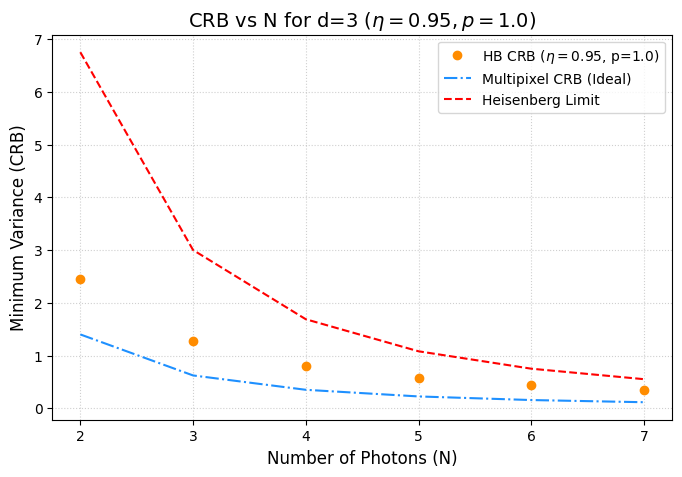

In [8]:

# == NEW PLOT: CRB vs N (number of photons) for fixed d, eta=0.95, p=1.0 ==

d_fixed = 3
eta_target = 0.95
p_target = 1.0

N_values = [2, 3, 4, 5, 6, 7]
crb_N_results = []
qfi_N_results = []

print(f"Evaluating N-dependence for d={d_fixed}, eta={eta_target}, p={p_target}...")
for N_test in N_values:
    # Initialize state
    hb_c, b_kets, cmbs = initialize_HB_state(N_test, d_fixed)
    initial_ket = construct_ket(hb_c, b_kets)
    
    # Evaluate metric
    qfi, crb = evaluate_state_metrics(initial_ket, N_test, d_fixed, [eta_target]*d_fixed, p_target)
    crb_N_results.append(crb)
    qfi_N_results.append(qfi)
    print(f"N={N_test} | QFI={qfi:.3f}, CRB={crb:.3f}")

plt.figure(figsize=(8, 5))
plt.plot(N_values, crb_N_results, marker='o', linestyle='None', color='darkorange', label=f'HB CRB ($\eta={eta_target}$, p={p_target})')

# Also plot the multipixel CRB and HL for reference
multipixel_crbs = [(d_fixed * (1 + np.sqrt(d_fixed))**2) / (4 * (n**2)) for n in N_values]
heisenberg_limits = [(d_fixed**3) / (n**2) for n in N_values]

plt.plot(N_values, multipixel_crbs, linestyle='-.', color='dodgerblue', label='Multipixel CRB (Ideal)')
plt.plot(N_values, heisenberg_limits, linestyle='--', color='red', label='Heisenberg Limit')

plt.xlabel("Number of Photons (N)", fontsize=12)
plt.ylabel(r"Minimum Variance (CRB)", fontsize=12)
plt.title(f"CRB vs N for d={d_fixed} ($\\eta={eta_target}, p={p_target}$)", fontsize=14)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()

filename_N = f"{out_folder_high}/CRB_vs_N_d{d_fixed}_eta{eta_target}_p{p_target}_scatter.png"
plt.savefig(filename_N, dpi=300, bbox_inches='tight')
print(f"Saved N-dependence plot to {filename_N}")
plt.show()


Evaluating d-dependence for N=6, eta=0.95, p=1.0...
d=1 | QFI=21.570, CRB=0.046
d=2 | QFI=28.156, CRB=0.181


<>:22: SyntaxWarning: invalid escape sequence '\e'
<>:22: SyntaxWarning: invalid escape sequence '\e'
C:\Users\omrym\AppData\Local\Temp\ipykernel_33492\2339690936.py:22: SyntaxWarning: invalid escape sequence '\e'
  plt.plot(d_values, crb_d_results, marker='s', linestyle='None', color='purple', label=f'HB CRB ($\eta={eta_target}$, p={p_target})')


d=3 | QFI=29.296, CRB=0.440


d=4 | QFI=29.909, CRB=0.818


Saved d-dependence plot to plots_output/HB_higher_dims/CRB_vs_d_N6_eta0.95_p1.0_scatter.png


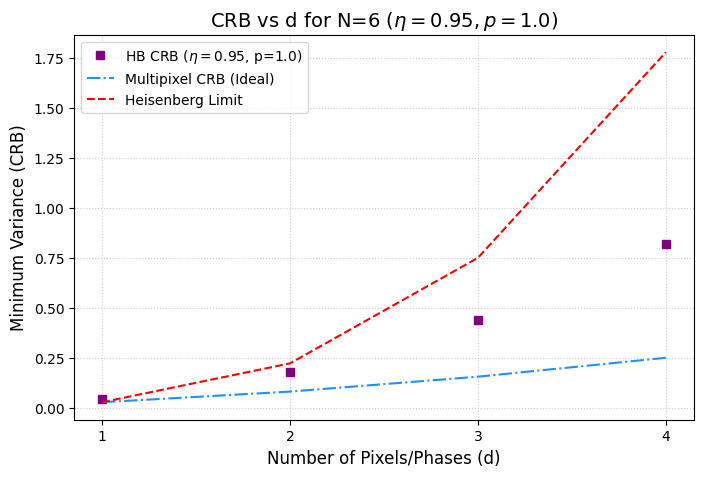

In [9]:

# == NEW PLOT: CRB vs d (number of pixels/phases) for fixed N, eta=0.95, p=1.0 ==

N_fixed = 6
eta_target = 0.95
p_target = 1.0

d_values = [1, 2, 3, 4]
crb_d_results = []

print(f"Evaluating d-dependence for N={N_fixed}, eta={eta_target}, p={p_target}...")
for d_test in d_values:
    # Initialize state
    hb_c, b_kets, cmbs = initialize_HB_state(N_fixed, d_test)
    initial_ket = construct_ket(hb_c, b_kets)
    
    # Evaluate metric
    qfi, crb = evaluate_state_metrics(initial_ket, N_fixed, d_test, [eta_target]*d_test, p_target)
    crb_d_results.append(crb)
    print(f"d={d_test} | QFI={qfi:.3f}, CRB={crb:.3f}")

plt.figure(figsize=(8, 5))
plt.plot(d_values, crb_d_results, marker='s', linestyle='None', color='purple', label=f'HB CRB ($\eta={eta_target}$, p={p_target})')

multipixel_crbs_d = [(d * (1 + np.sqrt(d))**2) / (4 * (N_fixed**2)) for d in d_values]
heisenberg_limits_d = [(d**3) / (N_fixed**2) for d in d_values]

plt.plot(d_values, multipixel_crbs_d, linestyle='-.', color='dodgerblue', label='Multipixel CRB (Ideal)')
plt.plot(d_values, heisenberg_limits_d, linestyle='--', color='red', label='Heisenberg Limit')

plt.xlabel("Number of Pixels/Phases (d)", fontsize=12)
plt.ylabel(r"Minimum Variance (CRB)", fontsize=12)
plt.title(f"CRB vs d for N={N_fixed} ($\\eta={eta_target}, p={p_target}$)", fontsize=14)
plt.xticks(d_values)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()

filename_d = f"{out_folder_high}/CRB_vs_d_N{N_fixed}_eta{eta_target}_p{p_target}_scatter.png"
plt.savefig(filename_d, dpi=300, bbox_inches='tight')
print(f"Saved d-dependence plot to {filename_d}")
plt.show()


In [10]:

# == FAST PURE STATE QFIM (ETA=1.0) ==

def calculate_QFIM_pure(coeffs, combs, d):
    # Mathematically exact and lightning fast QFIM calculation for pure states
    K = d
    qfim = np.zeros((K, K))
    n_exp = np.zeros(K)
    for idx, c in enumerate(coeffs):
        p = np.abs(c)**2
        for a in range(K):
            n_exp[a] += p * combs[idx][a]
            
    n_corr = np.zeros((K, K))
    for idx, c in enumerate(coeffs):
        p = np.abs(c)**2
        for a in range(K):
            for b in range(K):
                n_corr[a, b] += p * combs[idx][a] * combs[idx][b]
                
    for a in range(K):
        for b in range(K):
            qfim[a, b] = 4 * (n_corr[a, b] - n_exp[a] * n_exp[b])
    return qfim


Evaluating Fast Pure N-dependence for d=4, eta=1.0...
N=4 | QFI=17.920, CRB=1.429


<>:22: SyntaxWarning: invalid escape sequence '\e'
<>:32: SyntaxWarning: invalid escape sequence '\e'
<>:22: SyntaxWarning: invalid escape sequence '\e'
<>:32: SyntaxWarning: invalid escape sequence '\e'
C:\Users\omrym\AppData\Local\Temp\ipykernel_33492\1632327651.py:22: SyntaxWarning: invalid escape sequence '\e'
  plt.plot(N_values_pure, crb_N_pure_results, marker='o', linestyle='None', color='darkorange', label=f'HB CRB ($\eta=1.0$, Fast Pure)')
C:\Users\omrym\AppData\Local\Temp\ipykernel_33492\1632327651.py:32: SyntaxWarning: invalid escape sequence '\e'
  plt.title(f"CRB vs N for d={d_fixed} ($\eta=1.0, p=1.0$)", fontsize=14)


N=8 | QFI=52.480, CRB=0.488


N=12 | QFI=103.680, CRB=0.247


N=16 | QFI=171.520, CRB=0.149


Saved fast pure N-dependence plot to plots_output/HB_higher_dims/CRB_vs_N_d4_eta1.0_p1.0_scatter_pure.png


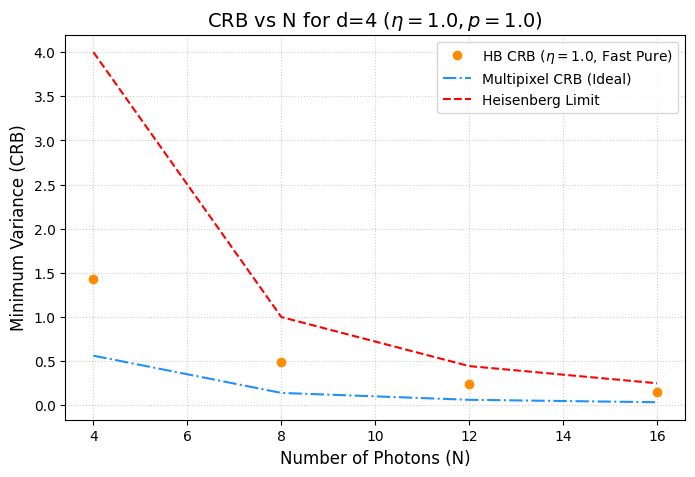

In [11]:

# == NEW PLOT: CRB vs N (number of photons) for fixed d=4, eta=1.0 ==
# Using Pure state fast calculation to overcome large D scaling memory limits

d_fixed = 4
N_values_pure = [4, 8, 12, 16]
crb_N_pure_results = []
qfi_N_pure_results = []

print(f"Evaluating Fast Pure N-dependence for d={d_fixed}, eta=1.0...")
for N_test in N_values_pure:
    hb_c, b_kets, cmbs = initialize_HB_state(N_test, d_fixed)
    
    qf_mat = calculate_QFIM_pure(hb_c, cmbs, d_fixed)
    qfi = np.trace(qf_mat)
    crb = np.trace(np.linalg.pinv(qf_mat)) if np.linalg.det(qf_mat) != 0 else np.inf
    
    crb_N_pure_results.append(crb)
    qfi_N_pure_results.append(qfi)
    print(f"N={N_test} | QFI={qfi:.3f}, CRB={crb:.3f}")

plt.figure(figsize=(8, 5))
plt.plot(N_values_pure, crb_N_pure_results, marker='o', linestyle='None', color='darkorange', label=f'HB CRB ($\eta=1.0$, Fast Pure)')

multipixel_crbs_pure = [(d_fixed * (1 + np.sqrt(d_fixed))**2) / (4 * (n**2)) for n in N_values_pure]
heisenberg_limits_pure = [(d_fixed**3) / (n**2) for n in N_values_pure]

plt.plot(N_values_pure, multipixel_crbs_pure, linestyle='-.', color='dodgerblue', label='Multipixel CRB (Ideal)')
plt.plot(N_values_pure, heisenberg_limits_pure, linestyle='--', color='red', label='Heisenberg Limit')

plt.xlabel("Number of Photons (N)", fontsize=12)
plt.ylabel(r"Minimum Variance (CRB)", fontsize=12)
plt.title(f"CRB vs N for d={d_fixed} ($\eta=1.0, p=1.0$)", fontsize=14)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()

filename_N_pure = f"{out_folder_high}/CRB_vs_N_d{d_fixed}_eta1.0_p1.0_scatter_pure.png"
plt.savefig(filename_N_pure, dpi=300, bbox_inches='tight')
print(f"Saved fast pure N-dependence plot to {filename_N_pure}")
plt.show()


Evaluating Fast Pure d-dependence for N=1, eta=1.0...


<>:19: SyntaxWarning: invalid escape sequence '\e'
<>:29: SyntaxWarning: invalid escape sequence '\e'
<>:19: SyntaxWarning: invalid escape sequence '\e'
<>:29: SyntaxWarning: invalid escape sequence '\e'
C:\Users\omrym\AppData\Local\Temp\ipykernel_33492\2728293504.py:19: SyntaxWarning: invalid escape sequence '\e'
  plt.plot(d_values_pure, crb_d_pure_results, marker='s', linestyle='None', color='purple', label=f'HB CRB ($\eta=1.0$, Fast Pure)')
C:\Users\omrym\AppData\Local\Temp\ipykernel_33492\2728293504.py:29: SyntaxWarning: invalid escape sequence '\e'
  plt.title(f"CRB vs d for N={N_fixed} ($\eta=1.0, p=1.0$)", fontsize=14)


d=1 | CRB=1.000
d=2 | CRB=3.000
d=3 | CRB=6.000
d=4 | CRB=10.000
d=5 | CRB=15.000
d=6 | CRB=21.000


Saved fast pure d-dependence plot to plots_output/HB_higher_dims/CRB_vs_d_N1_eta1.0_p1.0_scatter_pure.png


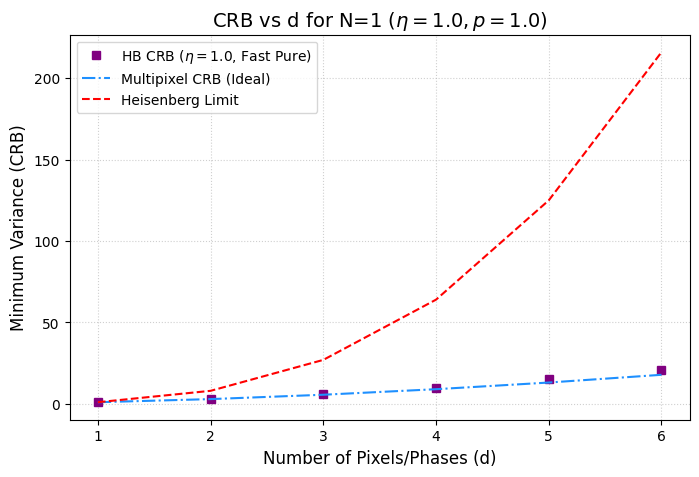

In [12]:

# == NEW PLOT: CRB vs d for fixed N=1, eta=1.0 ==

N_fixed = 1
d_values_pure = [1, 2, 3, 4, 5, 6]
crb_d_pure_results = []

print(f"Evaluating Fast Pure d-dependence for N={N_fixed}, eta=1.0...")
for d_test in d_values_pure:
    hb_c, b_kets, cmbs = initialize_HB_state(N_fixed, d_test)
    
    qf_mat = calculate_QFIM_pure(hb_c, cmbs, d_test)
    # Using generalized inverse since determinant might be 0 for some edge cases like d=1
    crb = np.trace(np.linalg.pinv(qf_mat))
    
    crb_d_pure_results.append(crb)
    print(f"d={d_test} | CRB={crb:.3f}")

plt.figure(figsize=(8, 5))
plt.plot(d_values_pure, crb_d_pure_results, marker='s', linestyle='None', color='purple', label=f'HB CRB ($\eta=1.0$, Fast Pure)')

multipixel_crbs_d_pure = [(d * (1 + np.sqrt(d))**2) / (4 * (N_fixed**2)) for d in d_values_pure]
heisenberg_limits_d_pure = [(d**3) / (N_fixed**2) for d in d_values_pure]

plt.plot(d_values_pure, multipixel_crbs_d_pure, linestyle='-.', color='dodgerblue', label='Multipixel CRB (Ideal)')
plt.plot(d_values_pure, heisenberg_limits_d_pure, linestyle='--', color='red', label='Heisenberg Limit')

plt.xlabel("Number of Pixels/Phases (d)", fontsize=12)
plt.ylabel(r"Minimum Variance (CRB)", fontsize=12)
plt.title(f"CRB vs d for N={N_fixed} ($\eta=1.0, p=1.0$)", fontsize=14)
plt.xticks(d_values_pure)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()

filename_d_pure = f"{out_folder_high}/CRB_vs_d_N{N_fixed}_eta1.0_p1.0_scatter_pure.png"
plt.savefig(filename_d_pure, dpi=300, bbox_inches='tight')
print(f"Saved fast pure d-dependence plot to {filename_d_pure}")
plt.show()


In [13]:

# == FAST PURE STATE QFIM (ETA=1.0) ==

def calculate_QFIM_pure(coeffs, combs, d):
    # Mathematically exact and lightning fast QFIM calculation for pure states
    K = d
    qfim = np.zeros((K, K))
    n_exp = np.zeros(K)
    for idx, c in enumerate(coeffs):
        p = np.abs(c)**2
        for a in range(K):
            n_exp[a] += p * combs[idx][a]
            
    n_corr = np.zeros((K, K))
    for idx, c in enumerate(coeffs):
        p = np.abs(c)**2
        for a in range(K):
            for b in range(K):
                n_corr[a, b] += p * combs[idx][a] * combs[idx][b]
                
    for a in range(K):
        for b in range(K):
            qfim[a, b] = 4 * (n_corr[a, b] - n_exp[a] * n_exp[b])
    return qfim


Evaluating Fast Pure N-dependence for d=3, eta=1.0...
N=4 (n=1) | CRB=0.750


N=8 (n=2) | CRB=0.250


N=12 (n=3) | CRB=0.125


N=16 (n=4) | CRB=0.075


Saved fast pure N-dependence plot to plots_output/Humphreys_Replications/Replication_Fig3a_CRB_vs_N_pure.png


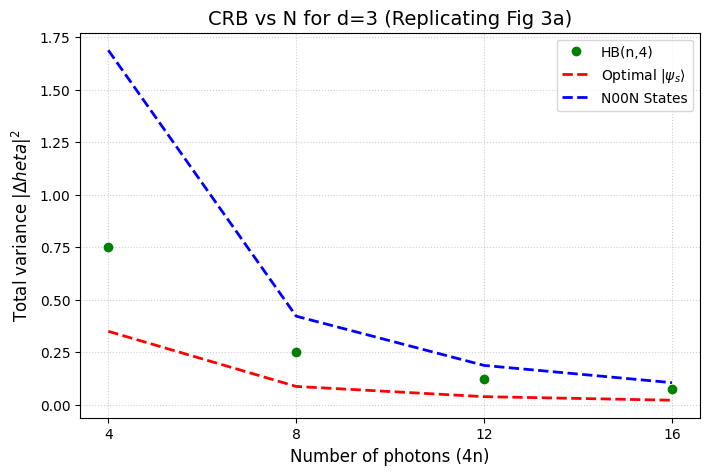

In [14]:

# == REPLICATING FIG 3(A): CRB vs n for fixed d=3 (Labeled internally by authors as HB(n,4) typo) ==
# Total Photons N = 4n

d_fixed = 3
n_values = [1, 2, 3, 4]
N_values_pure = [n * (d_fixed + 1) for n in n_values] # [4, 8, 12, 16]

crb_N_pure_results = []

print(f"Evaluating Fast Pure N-dependence for d={d_fixed}, eta=1.0...")
for N_test in N_values_pure:
    hb_c, b_kets, cmbs = initialize_HB_state(N_test, d_fixed)
    qf_mat = calculate_QFIM_pure(hb_c, cmbs, d_fixed)
    crb = np.trace(np.linalg.pinv(qf_mat))
    crb_N_pure_results.append(crb)
    print(f"N={N_test} (n={N_test//4}) | CRB={crb:.3f}")

plt.figure(figsize=(8, 5))
# HB (green, points no line)
plt.plot(N_values_pure, crb_N_pure_results, marker='o', linestyle='None', color='green', label=f'HB(n,{d_fixed+1})')

multipixel_crbs_pure = [(d_fixed * (1 + np.sqrt(d_fixed))**2) / (4 * (n**2)) for n in N_values_pure]
heisenberg_limits_pure = [(d_fixed**3) / (n**2) for n in N_values_pure]

# Optimal Multipixel (red dashed)
plt.plot(N_values_pure, multipixel_crbs_pure, linestyle='--', color='red', linewidth=2, label=r'Optimal $|\psi_s\rangle$')
# Heisenberg Limit (N00N) (blue dashed)
plt.plot(N_values_pure, heisenberg_limits_pure, linestyle='--', color='blue', linewidth=2, label='N00N States')

plt.xlabel(f"Number of photons ({d_fixed+1}n)", fontsize=12)
plt.ylabel(r"Total variance $|\Delta	heta|^2$", fontsize=12)
plt.title(f"CRB vs N for d={d_fixed} (Replicating Fig 3a)", fontsize=14)
plt.xticks(N_values_pure)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()

filename_N_pure = f"plots_output/Humphreys_Replications/Replication_Fig3a_CRB_vs_N_pure.png"
plt.savefig(filename_N_pure, dpi=300, bbox_inches='tight')
print(f"Saved fast pure N-dependence plot to {filename_N_pure}")
plt.show()


Evaluating Fast Pure d-dependence for n=1, eta=1.0...
d=1, N=2 | CRB=0.250
d=2, N=3 | CRB=0.500
d=3, N=4 | CRB=0.750
d=4, N=5 | CRB=1.000


d=5, N=6 | CRB=1.250


d=6, N=7 | CRB=1.500


Saved fast pure d-dependence plot to plots_output/Humphreys_Replications/Replication_Fig3b_CRB_vs_d_pure.png


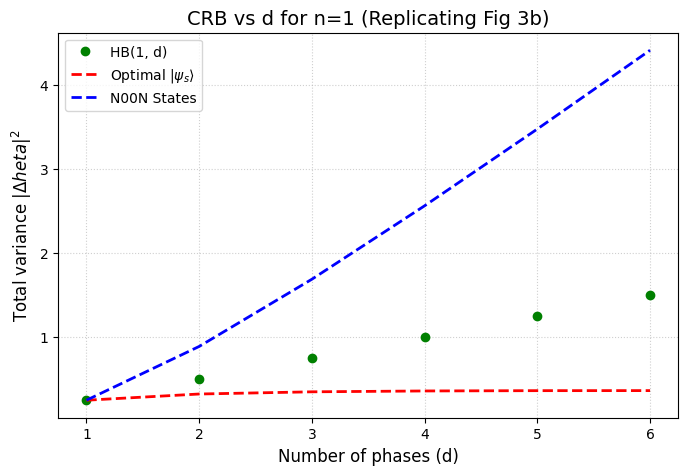

In [15]:

# == REPLICATING FIG 3(B): CRB vs d for fixed n=1 (Total Photons N = d+1) ==

n_fixed = 1
d_values_pure = [1, 2, 3, 4, 5, 6]
N_values_for_d = [n_fixed * (d + 1) for d in d_values_pure] # [2, 3, 4, 5, 6, 7]

crb_d_pure_results = []

print(f"Evaluating Fast Pure d-dependence for n={n_fixed}, eta=1.0...")
for d_test, N_test in zip(d_values_pure, N_values_for_d):
    hb_c, b_kets, cmbs = initialize_HB_state(N_test, d_test)
    qf_mat = calculate_QFIM_pure(hb_c, cmbs, d_test)
    crb = np.trace(np.linalg.pinv(qf_mat))
    crb_d_pure_results.append(crb)
    print(f"d={d_test}, N={N_test} | CRB={crb:.3f}")

plt.figure(figsize=(8, 5))
# HB (green, points no line)
plt.plot(d_values_pure, crb_d_pure_results, marker='o', linestyle='None', color='green', label=f'HB(1, d)')

multipixel_crbs_d_pure = [(d * (1 + np.sqrt(d))**2) / (4 * (N**2)) for d, N in zip(d_values_pure, N_values_for_d)]
heisenberg_limits_d_pure = [(d**3) / (N**2) for d, N in zip(d_values_pure, N_values_for_d)]

# Optimal Multipixel (red dashed)
plt.plot(d_values_pure, multipixel_crbs_d_pure, linestyle='--', color='red', linewidth=2, label=r'Optimal $|\psi_s\rangle$')
# Heisenberg Limit (N00N) (blue dashed)
plt.plot(d_values_pure, heisenberg_limits_d_pure, linestyle='--', color='blue', linewidth=2, label='N00N States')

plt.xlabel("Number of phases (d)", fontsize=12)
plt.ylabel(r"Total variance $|\Delta	heta|^2$", fontsize=12)
plt.title(f"CRB vs d for n={n_fixed} (Replicating Fig 3b)", fontsize=14)
plt.xticks(d_values_pure)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()

filename_d_pure = f"plots_output/Humphreys_Replications/Replication_Fig3b_CRB_vs_d_pure.png"
plt.savefig(filename_d_pure, dpi=300, bbox_inches='tight')
print(f"Saved fast pure d-dependence plot to {filename_d_pure}")
plt.show()


Starting Mixed Noise Sweep for Fig 3A (CRB vs n)
  eta=0.95, N=4 (n=1)


<>:49: SyntaxWarning: invalid escape sequence '\e'
<>:106: SyntaxWarning: invalid escape sequence '\e'
<>:49: SyntaxWarning: invalid escape sequence '\e'
<>:106: SyntaxWarning: invalid escape sequence '\e'
C:\Users\omrym\AppData\Local\Temp\ipykernel_33492\2899100700.py:49: SyntaxWarning: invalid escape sequence '\e'
  plt.plot(valid_N_a[eta], mixed_results_a[eta], marker='o', linestyle='None', color=colors[i], label=f'HB(n,{d_fixed_a+1}) $\eta={eta}$')
C:\Users\omrym\AppData\Local\Temp\ipykernel_33492\2899100700.py:106: SyntaxWarning: invalid escape sequence '\e'
  plt.plot(valid_d_b[eta], mixed_results_b[eta], marker='o', linestyle='None', color=colors[i], label=f'HB(1, d) $\eta={eta}$')


    Error 'float' object has no attribute 'isket' at N=4, capping limits.
  eta=0.9, N=4 (n=1)
    Error 'float' object has no attribute 'isket' at N=4, capping limits.
  eta=0.85, N=4 (n=1)
    Error 'float' object has no attribute 'isket' at N=4, capping limits.


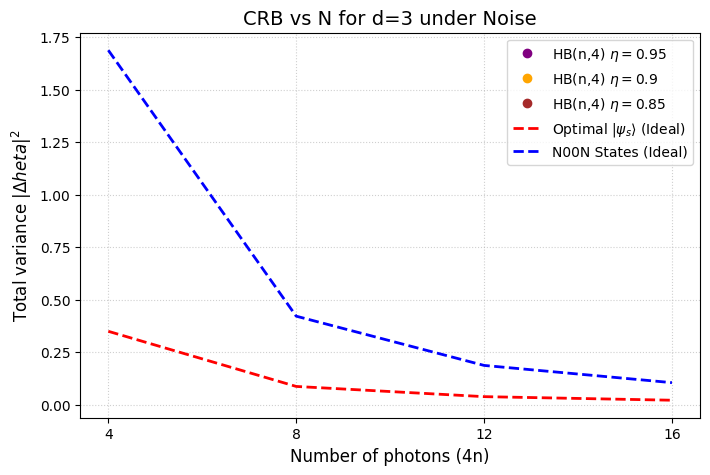

Starting Mixed Noise Sweep for Fig 3B (CRB vs d)
  eta=0.95, d=1, N=2
    Error 'float' object has no attribute 'isket' at d=1, capping limits.
  eta=0.9, d=1, N=2
    Error 'float' object has no attribute 'isket' at d=1, capping limits.
  eta=0.85, d=1, N=2
    Error 'float' object has no attribute 'isket' at d=1, capping limits.


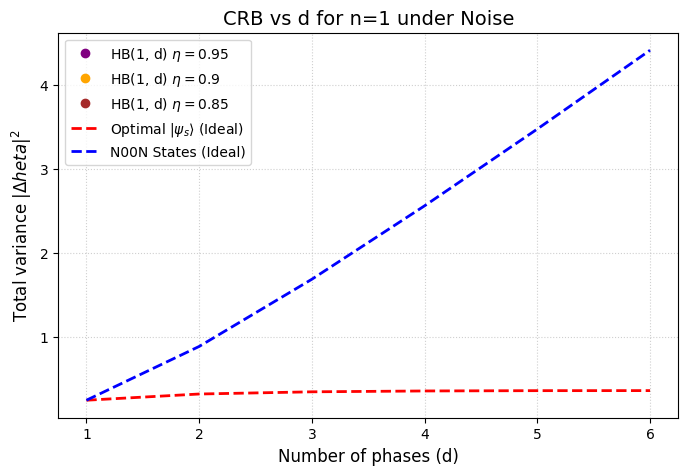

Completed Mixed state execution block!


In [16]:

# == REPLICATING FIG 3(A) & 3(B) UNDER MIXED NOISE (ETA = 0.95, 0.9, 0.85) ==
import gc

etas_to_test = [0.95, 0.90, 0.85]
p_val = 1.0 # Assuming non-correlated localized noise dominant for this scope

# --- FIG 3A: CRB vs N for fixed d=3 ---
d_fixed_a = 3
n_values_a = [1, 2, 3, 4]
N_values_a = [n * (d_fixed_a + 1) for n in n_values_a] # [4, 8, 12, 16]

mixed_results_a = {eta: [] for eta in etas_to_test}
valid_N_a = {eta: [] for eta in etas_to_test}

print("Starting Mixed Noise Sweep for Fig 3A (CRB vs n)")
for eta in etas_to_test:
    for n, N_test in zip(n_values_a, N_values_a):
        print(f"  eta={eta}, N={N_test} (n={n})")
        try:
            hb_c, b_kets, cmbs = initialize_HB_state(N_test, d_fixed_a)
            D_loc = N_test + 1
            
            # Reconstruct pure density matrix to feed into N_tot 
            # Note: memory heavy for N=12, 16
            rho_pure = 0
            for idx, c in enumerate(hb_c):
                if np.abs(c) > 1e-8:
                    n_0 = N_test - sum(cmbs[idx])
                    ket = tensor([basis(D_loc, n_0)] + [basis(D_loc, n_i) for n_i in cmbs[idx]])
                    rho_pure += c * ket
            rho_pure = rho_pure * rho_pure.dag()
            
            rho_out = N_tot(p_val, eta, D_loc, d_fixed_a, rho_pure)
            qfim = calculate_QFI_matrix_mixed(rho_out, d_fixed_a, D_loc, cmbs, N_test)
            crb = np.trace(np.linalg.pinv(qfim))
            mixed_results_a[eta].append(crb)
            valid_N_a[eta].append(N_test)
        except MemoryError:
            print(f"    MemoryError at N={N_test}, gracefully capping limits.")
            gc.collect()
            break
        except Exception as e:
            print(f"    Error {e} at N={N_test}, capping limits.")
            break

plt.figure(figsize=(8, 5))
colors = ['purple', 'orange', 'brown']
for i, eta in enumerate(etas_to_test):
    plt.plot(valid_N_a[eta], mixed_results_a[eta], marker='o', linestyle='None', color=colors[i], label=f'HB(n,{d_fixed_a+1}) $\eta={eta}$')

multipixel_crbs = [(d_fixed_a * (1 + np.sqrt(d_fixed_a))**2) / (4 * (n**2)) for n in N_values_a]
heisenberg_limits = [(d_fixed_a**3) / (n**2) for n in N_values_a]

plt.plot(N_values_a, multipixel_crbs, linestyle='--', color='red', linewidth=2, label=r'Optimal $|\psi_s\rangle$ (Ideal)')
plt.plot(N_values_a, heisenberg_limits, linestyle='--', color='blue', linewidth=2, label='N00N States (Ideal)')

plt.xlabel(f"Number of photons ({d_fixed_a+1}n)", fontsize=12)
plt.ylabel(r"Total variance $|\Delta	heta|^2$", fontsize=12)
plt.title(f"CRB vs N for d={d_fixed_a} under Noise", fontsize=14)
plt.xticks(N_values_a)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.savefig(f"plots_output/Humphreys_Replications/Replication_Fig3a_Mixed_Loss.png", dpi=300, bbox_inches='tight')
plt.show()

# --- FIG 3B: CRB vs d for fixed n=1 ---
n_fixed_b = 1
d_values_b = [1, 2, 3, 4, 5, 6]
N_values_b = [n_fixed_b * (d + 1) for d in d_values_b]

mixed_results_b = {eta: [] for eta in etas_to_test}
valid_d_b = {eta: [] for eta in etas_to_test}

print("Starting Mixed Noise Sweep for Fig 3B (CRB vs d)")
for eta in etas_to_test:
    for d_test, N_t in zip(d_values_b, N_values_b):
        print(f"  eta={eta}, d={d_test}, N={N_t}")
        try:
            hb_c, b_kets, cmbs = initialize_HB_state(N_t, d_test)
            D_loc = N_t + 1
            
            rho_pure = 0
            for idx, c in enumerate(hb_c):
                if np.abs(c) > 1e-8:
                    n_0 = N_t - sum(cmbs[idx])
                    ket = tensor([basis(D_loc, n_0)] + [basis(D_loc, n_i) for n_i in cmbs[idx]])
                    rho_pure += c * ket
            rho_pure = rho_pure * rho_pure.dag()
            
            rho_out = N_tot(p_val, eta, D_loc, d_test, rho_pure)
            qfim = calculate_QFI_matrix_mixed(rho_out, d_test, D_loc, cmbs, N_t)
            crb = np.trace(np.linalg.pinv(qfim))
            
            mixed_results_b[eta].append(crb)
            valid_d_b[eta].append(d_test)
        except MemoryError:
            print(f"    MemoryError at d={d_test}, gracefully capping limits.")
            gc.collect()
            break
        except Exception as e:
            print(f"    Error {e} at d={d_test}, capping limits.")
            break

plt.figure(figsize=(8, 5))
for i, eta in enumerate(etas_to_test):
    plt.plot(valid_d_b[eta], mixed_results_b[eta], marker='o', linestyle='None', color=colors[i], label=f'HB(1, d) $\eta={eta}$')

multipixel_d = [(d * (1 + np.sqrt(d))**2) / (4 * (N**2)) for d, N in zip(d_values_b, N_values_b)]
heisenberg_d = [(d**3) / (N**2) for d, N in zip(d_values_b, N_values_b)]

plt.plot(d_values_b, multipixel_d, linestyle='--', color='red', linewidth=2, label=r'Optimal $|\psi_s\rangle$ (Ideal)')
plt.plot(d_values_b, heisenberg_d, linestyle='--', color='blue', linewidth=2, label='N00N States (Ideal)')

plt.xlabel("Number of phases (d)", fontsize=12)
plt.ylabel(r"Total variance $|\Delta	heta|^2$", fontsize=12)
plt.title(f"CRB vs d for n={n_fixed_b} under Noise", fontsize=14)
plt.xticks(d_values_b)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.savefig(f"plots_output/Humphreys_Replications/Replication_Fig3b_Mixed_Loss.png", dpi=300, bbox_inches='tight')
plt.show()

print("Completed Mixed state execution block!")
